Imports

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

Load dataset and inspect basic info

In [ ]:
df = sns.load_dataset("titanic")

print("Dataset Shape (Rows, Columns):", df.shape)
print(df.head())
print(df.info())

Dataset Shape (Rows, Columns): (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       ------------

Statistical summary

In [ ]:
print(df.describe())

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


Check missing values

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
print("Missing values per column:\n", missing[missing > 0])

Missing values per column:
 deck           688
age            177
embarked         2
embark_town      2
dtype: int64


Clean the data

In [ ]:
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df = df.drop(columns=["deck"])

Survival rate by sex and by class

In [ ]:
survival_by_sex = df.groupby("sex")["survived"].mean()
print("Survival rate by sex:\n", survival_by_sex)
survival_by_class = df.groupby("pclass")["survived"].mean()
print("Survival rate by passenger class:\n", survival_by_class)

Survival rate by sex:
 sex
female    0.742038
male      0.188908
Name: survived, dtype: float64
Survival rate by passenger class:
 pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


Detect outliers in fare using the IQR method

In [ ]:
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df["fare"] < lower_bound) | (df["fare"] > upper_bound)]
print(f"Number of outliers in fare: {len(outliers)}")

Number of outliers in fare: 116


Correlation with survival

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()
print(correlation["survived"].sort_values(ascending=False))

survived    1.000000
fare        0.257307
parch       0.081629
sibsp      -0.035322
age        -0.064910
pclass     -0.338481
Name: survived, dtype: float64


Plot age distribution and correlation heatmap

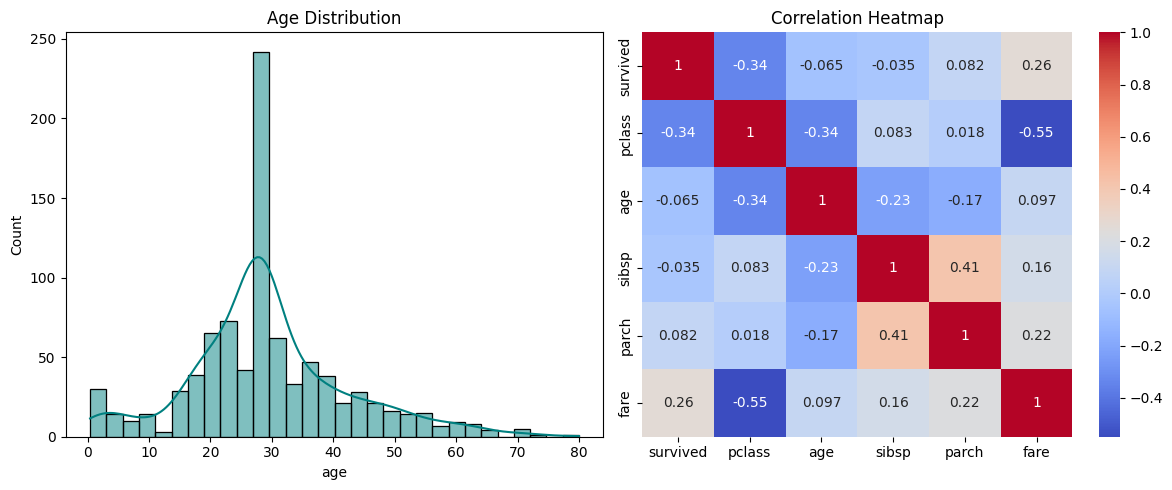

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df["age"], kde=True, ax=axes[0], color="teal")
axes[0].set_title("Age Distribution")

sns.heatmap(correlation, annot=True, cmap="coolwarm", ax=axes[1])
axes[1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("eda_summary.png")
plt.show()